✝ In memory of my beloved grandfather - Heshun Feng (冯和顺,1942-2026), who passed away today (11th July 2026).
  His love and encouragement will forever inspire me.
  
  ---

# Chapter 13 — Gaussian LIBOR Market Model_LMM

## A Beginner-Friendly Introduction to Forward-Rate Modeling

# 1. Introduction

This notebook introduces a compact Gaussian LIBOR Market Model (LMM), also interpretable as a discretized Gaussian HJM model on a tenor grid.

The complete pricing chain is:

```text
Initial zero curve
        ↓
Initial forward curve
        ↓
Forward-rate volatility
        ↓
Forward-rate correlation
        ↓
Terminal-measure drift
        ↓
Monte Carlo simulation
        ↓
Bond reconstruction
        ↓
Caplet and European swaption pricing
```

Hull-White simulates one short rate, while LMM simulates a vector of forward rates:

$$
L_0(t),L_1(t),\ldots,L_{N-1}(t).
$$

## Project Structure

```text
13_Gaussian LIBOR Market Model_LMM/
├── python/
│   ├── curve.py  (from previous chapter)
│   ├── market_data.py
│   ├── tenor_structure.py
│   ├── correlation.py
│   ├── volatility.py
│   ├── gaussian_lmm.py
│   ├── simulation.py
│   ├── pricing.py
│   ├── plotting.py
│   └── diagnostics.py
├── tests/
├── notebooks/
└── usd_zero_curve.csv
```

This chapter reuses `curve.py` from prevous chapters.

---
# 2. Imports and Paths



In [2]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.append("../python")

from market_data import load_curve_data
from tenor_structure import TenorStructure
from correlation import (
    exponential_correlation_matrix,
    stable_cholesky,
    principal_component_loadings,
)
from volatility import GaussianLMMVolatility
from gaussian_lmm import GaussianLMM
from simulation import simulate_gaussian_lmm, nearest_simulation_index
from pricing import (
    bond_prices_from_forwards,
    swap_annuity_and_rate,
    price_caplet_mc,
    price_payer_swaption_mc,
)
from plotting import (
    plot_initial_forward_curve,
    plot_forward_paths,
    plot_terminal_forward_distribution,
    plot_correlation_matrix,
    plot_mean_forward_surface,
)
from diagnostics import (
    forward_curve_table,
    summarize_simulation,
    check_correlation_matrix,
    print_pricing_summary,
)

plt.rcParams["figure.figsize"] = (10, 6)
print("Imports completed successfully.")

Imports completed successfully.


---
# 3. Initial Zero Curve

The model starts from discount factors:

$$
P(0,T)=e^{-z(0,T)T}.
$$

These discount factors are converted into discrete forward rates.

In [9]:
curve_file = "../data/usd_zero_curve.csv"
curve = load_curve_data(curve_file)

display_times = np.array([0.0, 0.5, 1.0, 2.0, 3.0, 5.0, 7.0, 10.0])
curve_rows = []

for t in display_times:

    discount_factor = curve.get_df(
        t
    )

    if t == 0.0:

        zero_rate = np.nan

    else:

        zero_rate = (
            -np.log(
                discount_factor
            )
            /
            t
        )

    curve_rows.append(
        {
            "time": t,
            "discount_factor": discount_factor,
            "zero_rate": zero_rate
        }
    )

curve_df = pd.DataFrame(
    curve_rows
)

curve_df

,time,discount_factor,zero_rate
0,0.0,1.000000,NaN
1,0.5,0.989555,0.0210
2,1.0,0.978240,0.0220
3,2.0,0.953134,0.0240
4,3.0,0.927743,0.0250
5,5.0,0.873716,0.0270
6,7.0,0.819140,0.0285
7,10.0,0.740818,0.0300


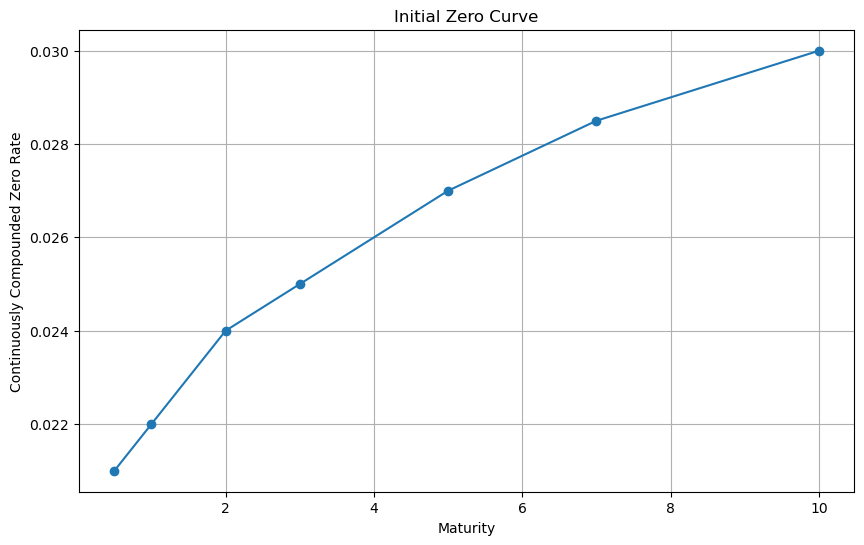

In [10]:
plt.figure()
plt.plot(curve_df["time"], curve_df["zero_rate"], marker="o")
plt.title("Initial Zero Curve")
plt.xlabel("Maturity")
plt.ylabel("Continuously Compounded Zero Rate")
plt.grid()
plt.show()

---
# 4. Tenor Structure and Initial Forwards

For tenor dates

$$
0=T_0<T_1<\cdots<T_N,
$$

the accrual is

$$
\delta_i=T_{i+1}-T_i.
$$

The simple forward rate satisfies

$$
1+\delta_iL_i(0)=\frac{P(0,T_i)}{P(0,T_{i+1})},
$$

so

$$
L_i(0)=\frac{P(0,T_i)/P(0,T_{i+1})-1}{\delta_i}.
$$

In [11]:
tenor = TenorStructure(start=0.0, end=10.0, payment_frequency=2)
initial_forwards = tenor.initial_forward_rates(curve)
initial_discount_factors = tenor.initial_discount_factors(curve)

print("Number of tenor dates:", len(tenor.times))
print("Number of forward rates:", tenor.n_forwards)
print("Accrual period:", tenor.delta)

Number of tenor dates: 21
Number of forward rates: 20
Accrual period: 0.5


In [12]:
forward_df = forward_curve_table(tenor, initial_forwards)
forward_df.head(10)

,reset_time,payment_time,accrual,initial_forward
0,0.0,0.5,0.5,0.021111
1,0.5,1.0,0.5,0.023133
2,1.0,1.5,0.5,0.025157
3,1.5,2.0,0.5,0.027183
4,2.0,2.5,0.5,0.026676
5,2.5,3.0,0.5,0.027690
6,3.0,3.5,0.5,0.028704
7,3.5,4.0,0.5,0.029719
8,4.0,4.5,0.5,0.030734
9,4.5,5.0,0.5,0.031749


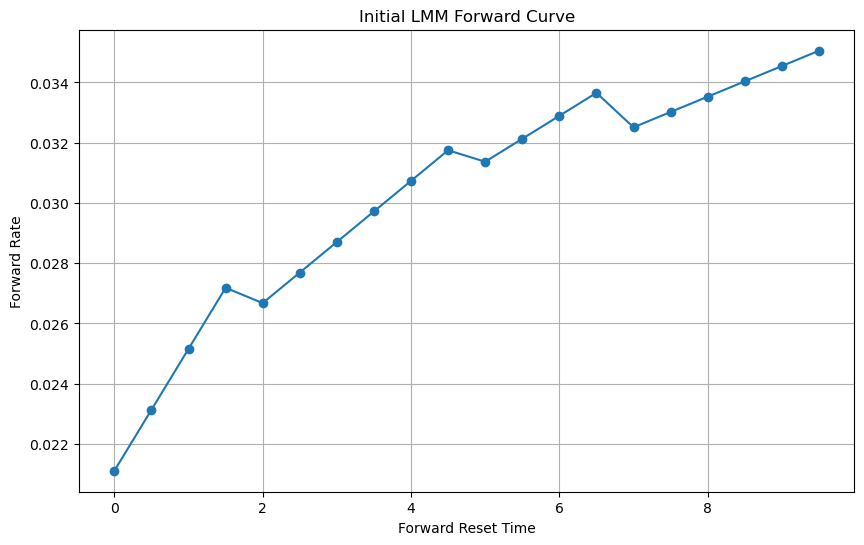

In [13]:
plot_initial_forward_curve(tenor, initial_forwards)

---
# 5. Libor Market Model

# 5.1 What Does LMM Simulate?

The state vector is

$$
\mathbf{L}(t)=\left(L_0(t),L_1(t),\ldots,L_{N-1}(t)\right).
$$

Each forward applies to one interval 

$$
[T_i,T_{i+1}].
$$

Once time reaches the reset date $T_i$, forward $L_i$ becomes fixed and stops evolving.

# 5.2 Gaussian LMM Dynamics

A lognormal LMM uses multiplicative diffusion:

$$
dL_i(t)=\mu_i(t)L_i(t)dt+L_i(t)\lambda_i(t)\cdot dW_t.
$$

This chapter uses additive Gaussian dynamics:

$$
dL_i(t)=\mu_i(t)dt+\lambda_i(t)\cdot dW_t.
$$

This is compatible with normal-volatility intuition and allows negative rates.

---
# 6. Correlation Across Forward Rates

We use

$$
\rho_{ij}=\exp\left(-\beta|T_i-T_j|\right).
$$

Small $\beta$ means persistent correlation; large $\beta$ means faster decay.

In [14]:
beta = 0.10
correlation_matrix = exponential_correlation_matrix(
    tenor.times[:-1], beta=beta
)

check_correlation_matrix(correlation_matrix)

{'minimum_eigenvalue': 0.0251491239883398,
 'maximum_eigenvalue': 14.789016141752644,
 'symmetric': True,
 'unit_diagonal': True}

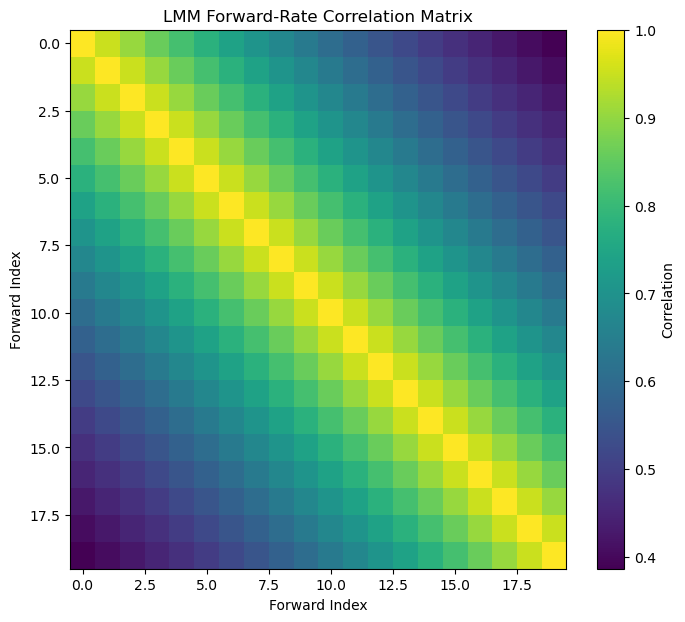

In [15]:
plot_correlation_matrix(correlation_matrix)

## Why does the code use `None`?

```python
distances = np.abs(
    reset_times[:, None] - reset_times[None, :]
)
```

`reset_times[:, None]` changes a one-dimensional array into a column vector.  
`reset_times[None, :]` changes it into a row vector.

Broadcasting then computes every pairwise distance.

In [16]:
example_times = np.array([0.5, 1.0, 1.5])
column_times = example_times[:, None]
row_times = example_times[None, :]

distance_example = np.abs(column_times - row_times)

print("Original shape:", example_times.shape)
print("Column shape:", column_times.shape)
print("Row shape:", row_times.shape)
distance_example

Original shape: (3,)
Column shape: (3, 1)
Row shape: (1, 3)


array([[0. , 0.5, 1. ],
       [0.5, 0. , 0.5],
       [1. , 0.5, 0. ]])

---
# 7. PCA Factor Reduction

The correlation matrix is decomposed as

$$
\rho=Q\Lambda Q^\top.
$$

Keeping the largest $m$ eigenvalues gives

$$
B=Q_m\Lambda_m^{1/2},
$$

and

$$
BB^\top\approx\rho.
$$

Three factors are commonly interpreted as level, slope, and curvature.

In [17]:
n_factors = 3
correlation_loadings = principal_component_loadings(
    correlation_matrix, n_factors=n_factors
)

print("Correlation matrix shape:", correlation_matrix.shape)
print("Reduced loading shape:", correlation_loadings.shape)

Correlation matrix shape: (20, 20)
Reduced loading shape: (20, 3)


In [18]:
approximated_correlation = correlation_loadings @ correlation_loadings.T
approximation_error = np.linalg.norm(
    correlation_matrix - approximated_correlation
)
print("PCA approximation error:", approximation_error)

PCA approximation error: 0.5702026306556172


---
# 8. Forward-Rate Volatility

We use

$$
\sigma_i(t)=\sigma_{\text{level}}\exp[-d(T_i-t)],\qquad t<T_i.
$$

After reset,

$$
\sigma_i(t)=0.
$$

In this Gaussian model, `sigma_level = 0.01` means roughly 100 basis points of annualized normal volatility.

In [19]:
volatility_model = GaussianLMMVolatility(
    reset_times=tenor.times[:-1],
    sigma_level=0.01,
    decay=0.05,
    floor=0.001,
)

vols_t0 = volatility_model.instantaneous_vols(t=0.0)
vols_t2 = volatility_model.instantaneous_vols(t=2.0)

pd.DataFrame({
    "reset_time": tenor.times[:-1],
    "vol_at_t0": vols_t0,
    "vol_at_t2": vols_t2,
}).head(12)

,reset_time,vol_at_t0,vol_at_t2
0,0.0,0.000000,0.000000
1,0.5,0.009753,0.000000
2,1.0,0.009512,0.000000
3,1.5,0.009277,0.000000
4,2.0,0.009048,0.000000
5,2.5,0.008825,0.009753
6,3.0,0.008607,0.009512
7,3.5,0.008395,0.009277
8,4.0,0.008187,0.009048
9,4.5,0.007985,0.008825


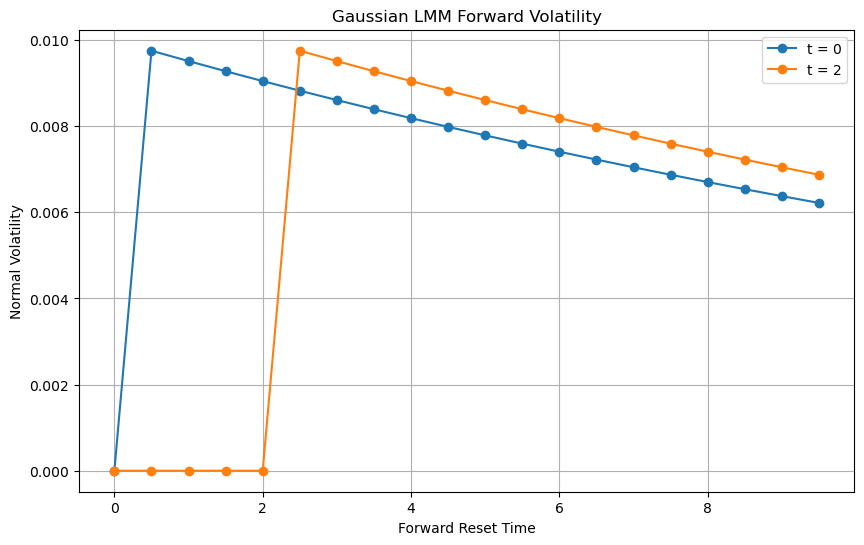

In [20]:
plt.figure()
plt.plot(tenor.times[:-1], vols_t0, marker="o", label="t = 0")
plt.plot(tenor.times[:-1], vols_t2, marker="o", label="t = 2")
plt.title("Gaussian LMM Forward Volatility")
plt.xlabel("Forward Reset Time")
plt.ylabel("Normal Volatility")
plt.legend()
plt.grid()
plt.show()

---
# 9. Factor Loadings

The final loading is

$$
\lambda_i(t)=\sigma_i(t)b_i.
$$

The instantaneous covariance is

$$
\operatorname{Cov}(dL_i,dL_j)
=
\lambda_i(t)\cdot\lambda_j(t)dt.
$$

In [21]:
factor_loadings_t0 = volatility_model.factor_loadings(
    t=0.0,
    correlation_loadings=correlation_loadings,
)

print("Factor-loading matrix shape:", factor_loadings_t0.shape)
pd.DataFrame(
    factor_loadings_t0[:8],
    columns=["Factor 1", "Factor 2", "Factor 3"],
)

Factor-loading matrix shape: (20, 3)


,Factor 1,Factor 2,Factor 3
0,0.000000,0.000000,-0.000000
1,0.007642,0.004811,-0.002710
2,0.007740,0.004604,-0.002195
3,0.007795,0.004254,-0.001474
4,0.007811,0.003779,-0.000633
5,0.007788,0.003201,0.000234
6,0.007730,0.002544,0.001033
7,0.007637,0.001835,0.001685


---
# 10. Build the Gaussian LMM

The model combines the tenor grid, initial forward curve, discount curve, volatility, and correlation factors.

The simulation measure is the terminal measure $Q^{T_N}$ with numeraire

$$
N(t)=P(t,T_N).
$$

In [22]:
lmm = GaussianLMM(
    tenor_structure=tenor,
    initial_forwards=initial_forwards,
    volatility_model=volatility_model,
    correlation_loadings=correlation_loadings,
    initial_discount_factors=initial_discount_factors,
)

lmm.summary()

{'model': 'Gaussian LIBOR Market Model',
 'measure': 'Terminal measure',
 'number_of_forwards': 20,
 'number_of_factors': 3,
 'tenor_start': 0.0,
 'tenor_end': 10.0,
 'terminal_discount_factor': 0.7408182206817179,
 'minimum_initial_forward': 0.021110636890052437,
 'maximum_initial_forward': 0.035053646696167284}

---
# 11. Terminal-Measure Drift

Under $Q^{T_N}$,

$$
dL_i(t)=\mu_i^{T_N}(t)dt+\lambda_i(t)\cdot dW_t^{T_N},
$$

with

$$
\mu_i^{T_N}(t)
=
-\sum_{j=i+1}^{N-1}
\frac{
\delta_j\lambda_i(t)\cdot\lambda_j(t)
}{
1+\delta_jL_j(t)
}.
$$

The last forward has zero drift because there are no later forwards in the sum.

In [23]:
drift_t0 = lmm.terminal_measure_drift(
    t=0.0,
    forward_rates=initial_forwards,
)

pd.DataFrame({
    "forward_index": np.arange(tenor.n_forwards),
    "reset_time": tenor.times[:-1],
    "initial_forward": initial_forwards,
    "terminal_measure_drift": drift_t0,
}).tail(8)

,forward_index,reset_time,initial_forward,terminal_measure_drift
12,12,6.0,0.032893,-0.000142
13,13,6.5,0.033655,-0.000121
14,14,7.0,0.032511,-0.000100
15,15,7.5,0.033020,-0.000079
16,16,8.0,0.033528,-0.000058
17,17,8.5,0.034036,-0.000038
18,18,9.0,0.034545,-0.000018
19,19,9.5,0.035054,-0.000000


In [24]:
print("Last-forward drift:", drift_t0[-1])

Last-forward drift: -0.0


---
# 12. One Euler Step

Euler discretization is

$$
\mathbf{L}_{t+\Delta t}
=
\mathbf{L}_t
+
\boldsymbol{\mu}_t\Delta t
+
\Lambda_t Z\sqrt{\Delta t}.
$$

If `Lambda` has shape `n_forwards × n_factors` and `Z` has length `n_factors`, then `Lambda @ Z` gives one diffusion shock for every forward.

In [25]:
rng = np.random.default_rng(123)
factor_shocks = rng.normal(size=lmm.n_factors)

next_forwards = lmm.evolve(
    t=0.0,
    forward_rates=initial_forwards,
    dt=0.05,
    factor_shocks=factor_shocks,
)

pd.DataFrame({
    "reset_time": tenor.times[:-1],
    "initial_forward": initial_forwards,
    "next_forward": next_forwards,
    "change": next_forwards - initial_forwards,
}).head(10)

,reset_time,initial_forward,next_forward,change
0,0.0,0.021111,0.021111,0.000000
1,0.5,0.023133,0.020244,-0.002889
2,1.0,0.025157,0.022414,-0.002743
3,1.5,0.027183,0.024666,-0.002517
4,2.0,0.026676,0.024438,-0.002238
5,2.5,0.027690,0.025755,-0.001935
6,3.0,0.028704,0.027068,-0.001636
7,3.5,0.029719,0.028351,-0.001368
8,4.0,0.030734,0.029583,-0.001151
9,4.5,0.031749,0.030751,-0.000998


---
# 13. Monte Carlo Simulation

The simulation array has shape

```text
n_paths × (n_steps + 1) × n_forwards
```

`forward_paths[p, k, i]` is forward $i$ on path $p$ at simulation time index $k$.

In [26]:
simulation_end = 5.0
n_steps = 100
n_paths = 5000

times, forward_paths = simulate_gaussian_lmm(
    model=lmm,
    simulation_end=simulation_end,
    n_steps=n_steps,
    n_paths=n_paths,
    seed=42,
    antithetic=True,
)

print("Time-grid shape:", times.shape)
print("Forward-path shape:", forward_paths.shape)

Time-grid shape: (101,)
Forward-path shape: (5000, 101, 20)


## 13.1 Antithetic Variates

The simulator pairs each shock $Z$ with $-Z$. This often reduces Monte Carlo noise without changing the expected value.

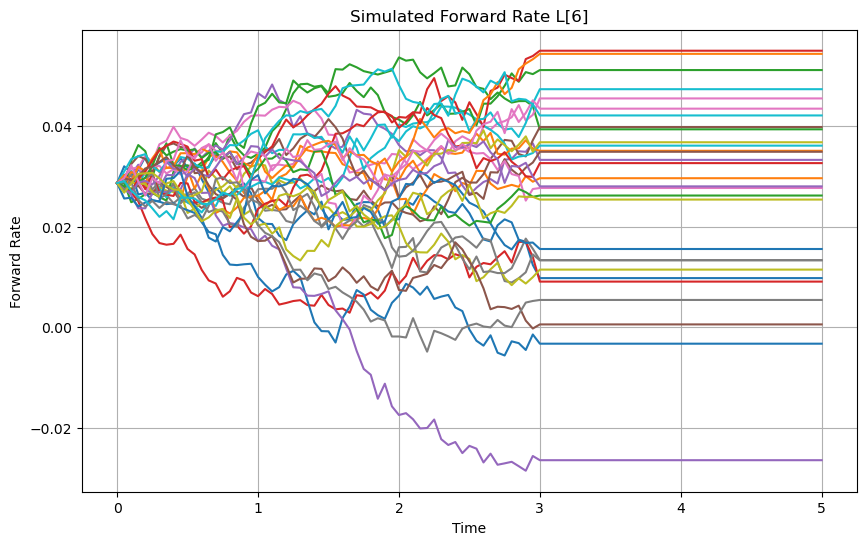

In [27]:
plot_forward_paths(
    times=times,
    forward_paths=forward_paths,
    forward_index=6,
    n_plot=30,
)

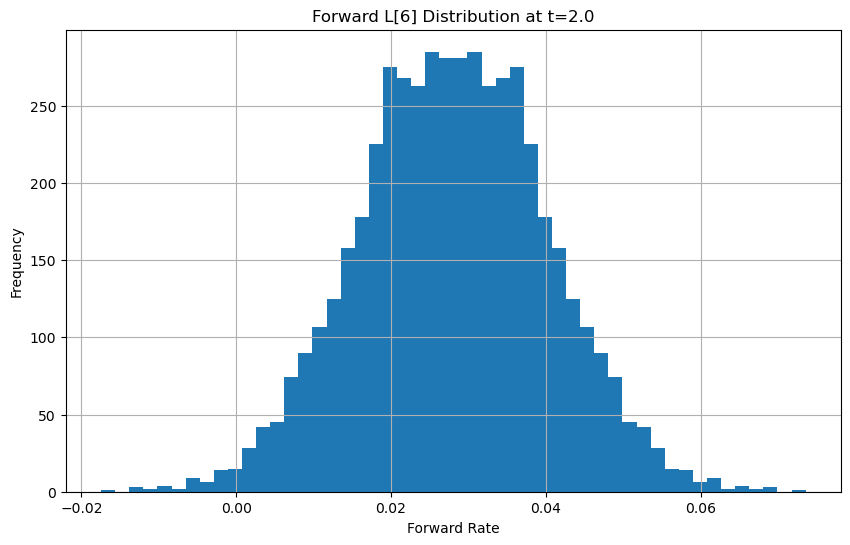

In [28]:
plot_terminal_forward_distribution(
    times=times,
    forward_paths=forward_paths,
    forward_index=6,
    target_time=2.0,
)

## 13.2 Simulation Diagnostics

Each forward is summarized at its own reset date.

In [29]:
simulation_summary = summarize_simulation(
    times,
    forward_paths,
    tenor,
)
simulation_summary.head(12)

,forward_index,reset_time,mean,std,min,max
0,0,0.0,0.021111,0.000000,0.021111,0.021111
1,1,0.5,0.022903,0.006737,-0.001119,0.046924
2,2,1.0,0.024722,0.009472,-0.005377,0.054822
3,3,1.5,0.026569,0.011316,-0.018813,0.071950
4,4,2.0,0.025905,0.012887,-0.021456,0.073266
5,5,2.5,0.026782,0.014151,-0.027000,0.080565
6,6,3.0,0.027682,0.015535,-0.026449,0.081812
7,7,3.5,0.028605,0.016557,-0.032173,0.089383
8,8,4.0,0.029557,0.017706,-0.042285,0.101399
9,9,4.5,0.030537,0.018759,-0.041187,0.102261


---
# 14. Pricing Examples

## 14.1 Reconstruct Discount Bonds

At tenor date $T_k$,

$$
P(T_k,T_k)=1,
$$

and

$$
P(T_k,T_{j+1})
=
\frac{P(T_k,T_j)}{1+\delta_jL_j(T_k)}.
$$

Thus,

$$
P(T_k,T_j)
=
\prod_{m=k}^{j-1}
\frac{1}{1+\delta_mL_m(T_k)}.
$$

In [30]:
valuation_time = 2.0
sim_index = nearest_simulation_index(times, valuation_time)
tenor_index = tenor.time_index(valuation_time)

sample_forward_state = forward_paths[0, sim_index, :]
sample_bonds = bond_prices_from_forwards(
    sample_forward_state,
    tenor,
    start_forward_index=tenor_index,
)

pd.DataFrame({
    "tenor_time": tenor.times,
    "bond_price": sample_bonds,
}).iloc[tenor_index:tenor_index + 10]

,tenor_time,bond_price
4,2.0,1.000000
5,2.5,0.990200
6,3.0,0.980113
7,3.5,0.969687
8,4.0,0.958847
9,4.5,0.947509
10,5.0,0.935588
11,5.5,0.923650
12,6.0,0.911106
13,6.5,0.897931


# 14.2 Swap Annuity and Par Swap Rate

For a swap from $T_k$ to $T_m$,

$$
A(T_k)=\sum_{j=k}^{m-1}\delta_jP(T_k,T_{j+1}),
$$

and

$$
S(T_k)=\frac{1-P(T_k,T_m)}{A(T_k)}.
$$

In [31]:
swap_start_index = tenor.time_index(2.0)
swap_end_index = tenor.time_index(7.0)

sample_annuity, sample_swap_rate = swap_annuity_and_rate(
    sample_forward_state,
    tenor,
    swap_start_index,
    swap_end_index,
)

print("Sample annuity:", sample_annuity)
print("Sample par swap rate:", sample_swap_rate)

Sample annuity: 4.699381954251823
Sample par swap rate: 0.024656048321803466


# 14.3 Terminal Numeraire Pricing

Under the terminal measure,

$$
V(0)
=
P(0,T_N)
\mathbb{E}^{T_N}
\left[
\frac{V(T)}{P(T,T_N)}
\right].
$$

This is why the code multiplies the average numeraire-adjusted payoff by the initial terminal discount factor.

# 14.4 Caplet Pricing

A caplet fixes at $T_i$ and pays at $T_{i+1}$:

$$
N\delta_i\max(L_i(T_i)-K,0).
$$

At reset time, the value is

$$
\frac{N\delta_i\max(L_i(T_i)-K,0)}{1+\delta_iL_i(T_i)}.
$$

In [32]:
caplet_price = price_caplet_mc(
    model=lmm,
    times=times,
    forward_paths=forward_paths,
    reset_time=2.0,
    strike=0.045,
    notional=1_000_000,
)

print("Caplet price:", caplet_price)

Caplet price: 206.91326657260555


# 14.5 European Payer Swaption Pricing

At expiry $T_k$, the payer swaption payoff is

$$
N A(T_k)\max(S(T_k)-K,0).
$$

Each path reconstructs bonds, computes the annuity and swap rate, and applies terminal-numeraire pricing.

In [33]:
swaption_price = price_payer_swaption_mc(
    model=lmm,
    times=times,
    forward_paths=forward_paths,
    expiry=2.0,
    swap_end=7.0,
    strike=0.045,
    notional=1_000_000,
)

print("Payer swaption price:", swaption_price)

Payer swaption price: 2089.3106378756643


In [34]:
print_pricing_summary(caplet_price, swaption_price)

Gaussian LMM Pricing Summary
Caplet price          : 206.913267
Payer swaption price : 2,089.310638


---
# 15. Sensitivity Analysis

## 15.1 Strike Sensitivity

For payer options, higher strikes should generally reduce value.

In [35]:
strikes = np.array([0.035, 0.040, 0.045, 0.050, 0.055])
rows = []

for strike in strikes:
    rows.append({
        "strike": strike,
        "caplet_price": price_caplet_mc(
            lmm, times, forward_paths, 2.0, strike, 1_000_000
        ),
        "swaption_price": price_payer_swaption_mc(
            lmm, times, forward_paths, 2.0, 7.0, strike, 1_000_000
        ),
    })

strike_df = pd.DataFrame(rows)
strike_df

,strike,caplet_price,swaption_price
0,0.035,936.137683,10984.074772
1,0.040,462.131867,5192.694100
2,0.045,206.913267,2089.310638
3,0.050,83.978871,728.940270
4,0.055,31.269184,233.953351


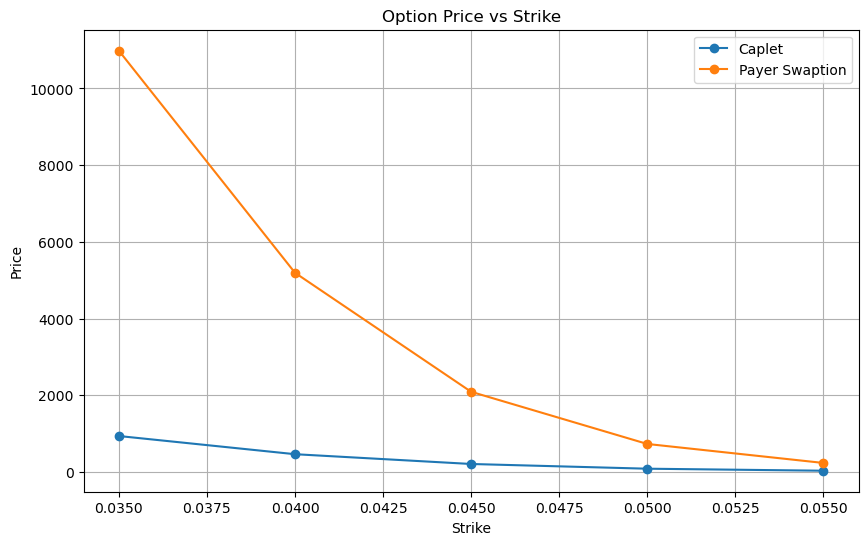

In [36]:
plt.figure()
plt.plot(strike_df["strike"], strike_df["caplet_price"], marker="o", label="Caplet")
plt.plot(strike_df["strike"], strike_df["swaption_price"], marker="o", label="Payer Swaption")
plt.title("Option Price vs Strike")
plt.xlabel("Strike")
plt.ylabel("Price")
plt.legend()
plt.grid()
plt.show()

## 15.2 Volatility Sensitivity

Higher volatility should generally increase option value.

In [39]:
sigma_levels = [0.005, 0.010, 0.015]
rows = []

for sigma_level in sigma_levels:
    vol_model_sigma = GaussianLMMVolatility(
        reset_times=tenor.times[:-1],
        sigma_level=sigma_level,
        decay=0.05,
        floor=0.001,
    )

    model_sigma = GaussianLMM(
        tenor_structure=tenor,
        initial_forwards=initial_forwards,
        volatility_model=vol_model_sigma,
        correlation_loadings=correlation_loadings,
        initial_discount_factors=initial_discount_factors,
    )

    times_sigma, paths_sigma = simulate_gaussian_lmm(
        model=model_sigma,
        simulation_end=5.0,
        n_steps=100,
        n_paths=3000,
        seed=42,
        antithetic=True,
    )

    rows.append({
        "sigma_level": sigma_level,
        "caplet_price": price_caplet_mc(
            model_sigma, times_sigma, paths_sigma, 2.0, 0.045, 1_000_000
        ),
        "swaption_price": price_payer_swaption_mc(
            model_sigma, times_sigma, paths_sigma, 2.0, 7.0, 0.045, 1_000_000
        ),
    })

vol_sensitivity_df = pd.DataFrame(rows)
vol_sensitivity_df

,sigma_level,caplet_price,swaption_price
0,0.005,4.245439,56.875913
1,0.010,239.623675,2338.099224
2,0.015,883.320160,7920.022525


## 15.3 Correlation Sensitivity

A caplet mainly depends on one forward. A swaption depends on the joint movement of several forwards, so correlation is especially important for swaption pricing.

In [40]:
betas = [0.05, 0.10, 0.30]
rows = []

for beta_value in betas:
    corr_beta = exponential_correlation_matrix(
        tenor.times[:-1], beta=beta_value
    )
    loadings_beta = principal_component_loadings(
        corr_beta, n_factors=3
    )

    model_beta = GaussianLMM(
        tenor_structure=tenor,
        initial_forwards=initial_forwards,
        volatility_model=volatility_model,
        correlation_loadings=loadings_beta,
        initial_discount_factors=initial_discount_factors,
    )

    times_beta, paths_beta = simulate_gaussian_lmm(
        model=model_beta,
        simulation_end=5.0,
        n_steps=100,
        n_paths=3000,
        seed=42,
        antithetic=True,
    )

    rows.append({
        "beta": beta_value,
        "swaption_price": price_payer_swaption_mc(
            model_beta, times_beta, paths_beta, 2.0, 7.0, 0.045, 1_000_000
        ),
    })

correlation_sensitivity_df = pd.DataFrame(rows)
correlation_sensitivity_df

,beta,swaption_price
0,0.05,2689.807272
1,0.10,2338.099224
2,0.30,1280.937040


---
# 16. Summary

## 16.1 Five-File Architecture

- `correlation.py`: how different forwards move together.
- `volatility.py`: how much each forward moves.
- `gaussian_lmm.py`: drift, diffusion, and one-step dynamics.
- `simulation.py`: repeated evolution across paths and times.
- `pricing.py`: bond reconstruction, swap rates, payoffs, and Monte Carlo valuation.

## 16.2 Limitations

This is a compact educational implementation:

1. additive Gaussian dynamics;
2. deterministic volatility;
3. exponential correlation;
4. PCA factor reduction;
5. Euler discretization;
6. no market calibration;
7. no smile or skew.

Chapter 14 will add SABR-style stochastic volatility.

## 16.3 Final Takeaways

1. LMM simulates forward rates directly.
2. Correlation controls joint curve movement.
3. Volatility controls movement size.
4. Terminal-measure drift is measure-dependent.
5. Monte Carlo produces future forward curves.
6. Forward curves reconstruct bonds.
7. Bonds produce annuities and swap rates.
8. Caplets depend mainly on one forward.
9. Swaptions depend on several correlated forwards.
10. Terminal-measure pricing uses $P(0,T_N)$ and $P(T,T_N)$.

## 16.4 Next Chapter — LMM-SABR Hybrid Model

The Gaussian LMM developed in this chapter captures the joint evolution of the forward curve through:

- multiple forward rates,
- tenor-dependent volatility,
- cross-maturity correlation,
- terminal-measure drift,
- and Monte Carlo pricing.

However, its volatility is deterministic and Gaussian, so it cannot reproduce the volatility smile and skew observed in caplet and swaption markets.

Chapter 14 extends this framework by introducing SABR-style stochastic volatility into the LMM:

```text
Gaussian LMM
    +
SABR stochastic volatility
    ↓
LMM-SABR Hybrid Model